In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os
from astropy.modeling import models
import astropy.units as u

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC3141/UGC-3141_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC3141/UGC-3141_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     371   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        52   (2094, 964)   float32   


In [4]:
image_cut = image[90:210, 0:1890]
image_error_cut = image_error[90:210, 0:1890]

Text(0.5, 0, 'wavelenght')

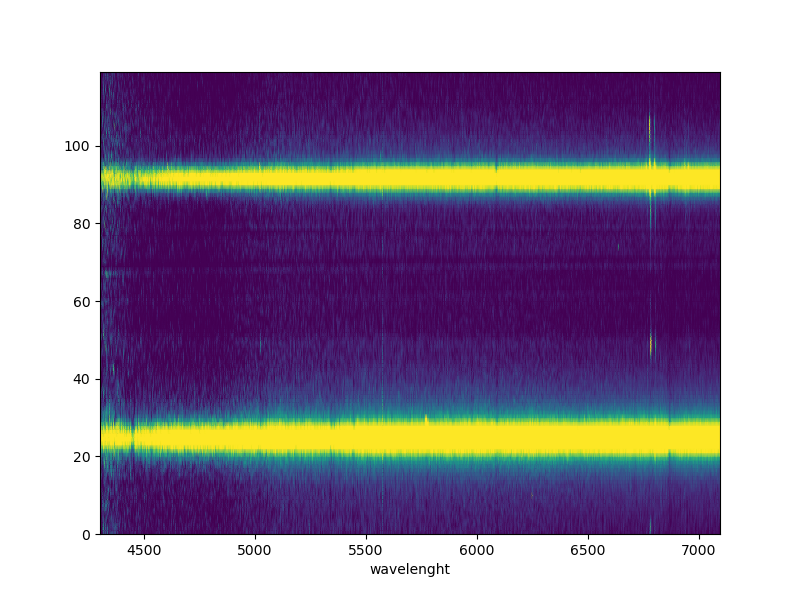

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(8,6))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

In [6]:
z = 0.03401
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII_1 = 6548 * (1+z) 
l_NII_2 = 6583 * (1+z)
l_SII_1 = 6717 * (1+z)
l_SII_2 = 6731 * (1+z)
l_OIII_1 = 4959 * (1+z)
l_OIII_2 = 5007 * (1+z)

In [7]:
l_HA

6786.207630000001

Text(0, 0.5, 'Flux [$10^{-16} erg/(cm^2 s \\AA )$]')

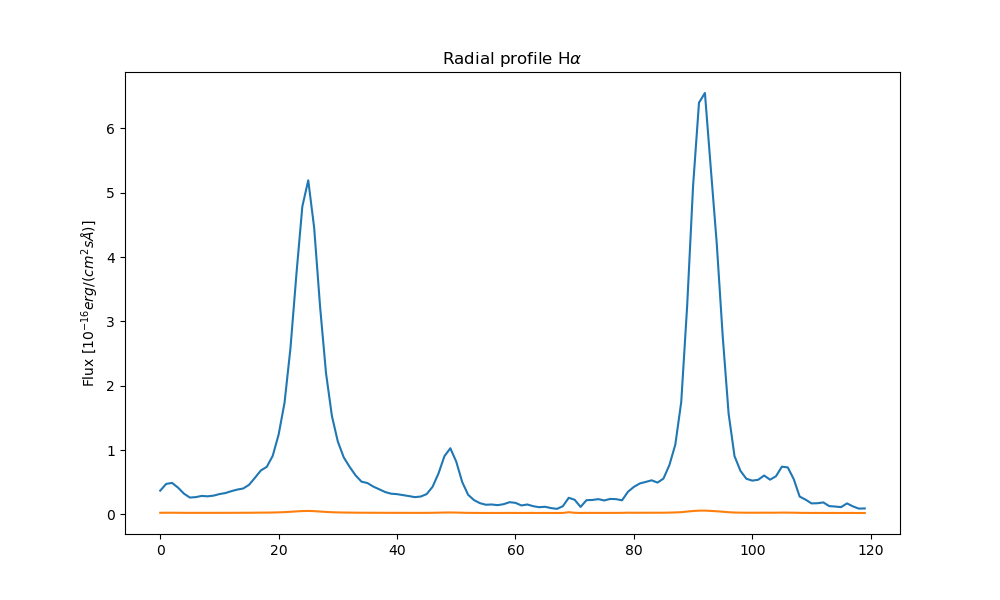

In [8]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 120, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'Radial profile H$\alpha$')
plt.ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')

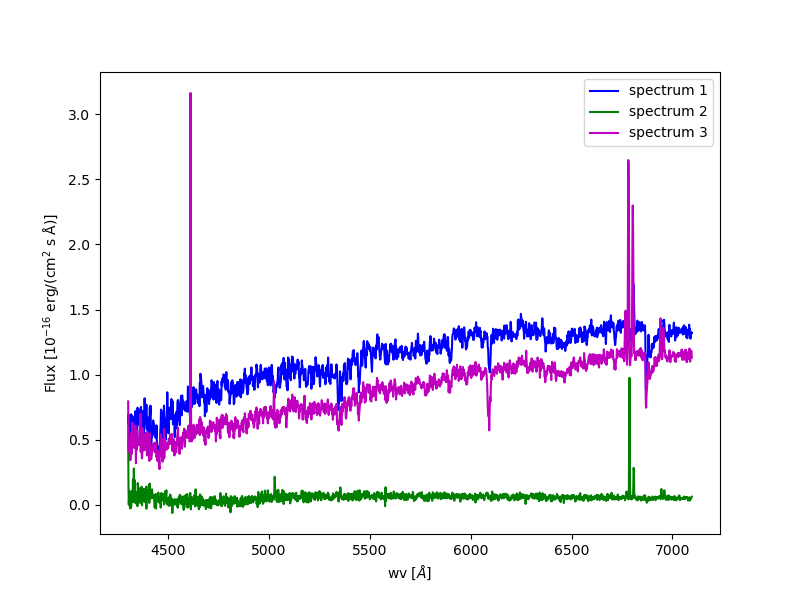

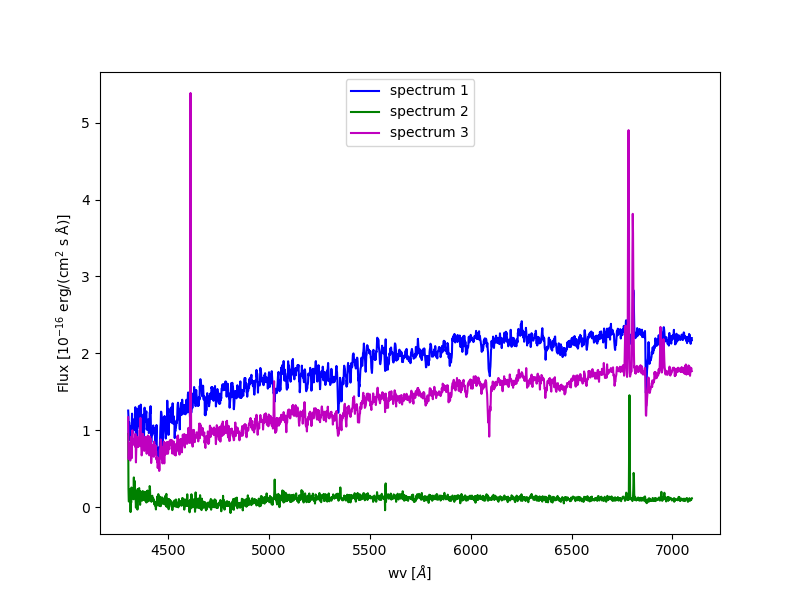

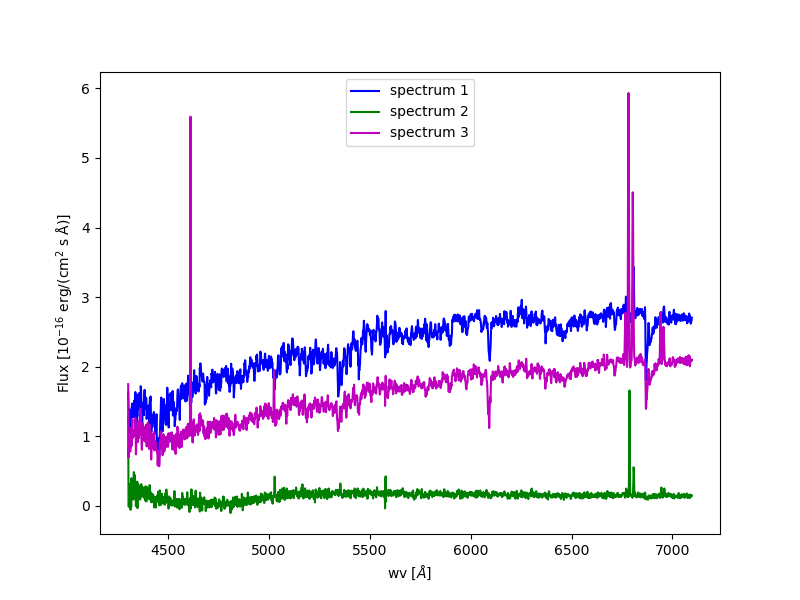

In [9]:
fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC3141/Fit/Halpha_fit.csv", index_col=0)
os.makedirs('1Sigma', exist_ok=True)
os.makedirs('2Sigma', exist_ok=True)
os.makedirs('3Sigma', exist_ok=True)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC3141/PSF/Real_seeing_UGC3141.txt")
sigma = seeing[-1]/2.35
peaks = fit_HA.iloc[3].values

plt.figure(figsize=(8,6))
spectra_1 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_1 = np.zeros((len(peaks), image_error_cut.shape[1]))
data1 = []
colors = ['blue', 'green','m' ]#, 'orange', 'dodgerblue', 'darkblue']
#Cut one sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-sigma)*(x_axes < peaks[i]+sigma)
    spectra_1[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_1[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_1[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_1[i].reshape(-1, 1), spectra_err_1[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('1Sigma', f'Spectrum_1s_{i+1}.txt')  
    np.savetxt(filename, spectrum_table)

plt.figure(figsize=(8,6))
spectra_2 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_2 = np.zeros((len(peaks), image_error_cut.shape[1]))
data2 = []

#Cut two sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-2*sigma)*(x_axes < peaks[i]+2*sigma)
    spectra_2[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_2[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_2[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_2[i].reshape(-1, 1), spectra_err_2[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('2Sigma', f'Spectrum_2s_{i+1}.txt')  
    np.savetxt(filename, spectrum_table)
    
plt.figure(figsize=(8,6))
spectra_3 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_3 = np.zeros((len(peaks), image_error_cut.shape[1]))
data3 = []
#Cut three sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-3*sigma)*(x_axes < peaks[i]+3*sigma)
    spectra_3[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_3[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_3[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_3[i].reshape(-1, 1), spectra_err_3[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('3Sigma', f'Spectrum_3s_{i+1}.txt') 
    np.savetxt(filename, spectrum_table)

## S/N continuum
Fare segnale/rumore per ogni pixel e poi fai la media, questo per le tre regioni

In [10]:
import pandas as pd

mask_continuum_1 = (wv > 4650)*(wv < 4950)
mask_continuum_2 = (wv > 5400)*(wv < 5700)
mask_continuum_3 = (wv > 6140)*(wv < 6440)

# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []

# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_1[i, mask_continuum_1])
    noise_1 = np.std(spectra_1[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_1[i, mask_continuum_2])
    noise_2 = np.std(spectra_1[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_1[i, mask_continuum_3])
    noise_3 = np.std(spectra_1[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)

# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]

# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)

print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)

# Salvataggio dei file
df_path_snr = os.path.join('1Sigma', 'SNR_1s_continuum.csv')
df_path_signal = os.path.join('1Sigma', 'Signal_1s_continuum.csv')
df_path_noise = os.path.join('1Sigma', 'Noise_1s_continuum.csv')
df_path_combined = os.path.join('1Sigma', 'Combined_1s_continuum.csv')

# Assicurati che la directory esista
os.makedirs('1Sigma', exist_ok=True)

df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')

print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3
Continuum_1   12.882843    1.101874   11.892911
Continuum_2   16.308185    3.557064   15.230013
Continuum_3   26.535746    4.043609   26.776663

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3
Continuum_1    0.899183    0.028396    0.612412
Continuum_2    1.156771    0.068052    0.864018
Continuum_3    1.318084    0.059886    1.055319

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3
Continuum_1    0.069797    0.025771    0.051494
Continuum_2    0.070932    0.019132    0.056731
Continuum_3    0.049672    0.014810    0.039412

DataFrame Combinato:
                   SNR                           Signal                        \
            Spectrum_1 Spectrum_2 Spectrum_3 Spectrum_1 Spectrum_2 Spectrum_3   
Continuum_1  12.882843   1.101874  11.892911   0.899183   0.028396   0.612412   
Continuum_2  16.308185   3.557064  15.230013   1.156771   0.068052   0.864018   
Continuum_3  26.535746   4

In [11]:
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []

# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_2[i, mask_continuum_1])
    noise_1 = np.std(spectra_2[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_2[i, mask_continuum_2])
    noise_2 = np.std(spectra_2[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_2[i, mask_continuum_3])
    noise_3 = np.std(spectra_2[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)

# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]

# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)

print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)

# Salvataggio dei file
df_path_snr = os.path.join('2Sigma', 'SNR_2s_continuum.csv')
df_path_signal = os.path.join('2Sigma', 'Signal_2s_continuum.csv')
df_path_noise = os.path.join('2Sigma', 'Noise_2s_continuum.csv')
df_path_combined = os.path.join('2Sigma', 'Combined_2s_continuum.csv')

# Assicurati che la directory esista
os.makedirs('2Sigma', exist_ok=True)

df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')

print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3
Continuum_1   14.191175    1.108585   13.530445
Continuum_2   16.562551    3.973520   16.407847
Continuum_3   28.412592    5.343946   27.348700

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3
Continuum_1    1.503158    0.044996    0.988517
Continuum_2    1.943095    0.131033    1.381149
Continuum_3    2.172232    0.113287    1.636002

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3
Continuum_1    0.105922    0.040589    0.073059
Continuum_2    0.117319    0.032977    0.084176
Continuum_3    0.076453    0.021199    0.059820

DataFrame Combinato:
                   SNR                           Signal                        \
            Spectrum_1 Spectrum_2 Spectrum_3 Spectrum_1 Spectrum_2 Spectrum_3   
Continuum_1  14.191175   1.108585  13.530445   1.503158   0.044996   0.988517   
Continuum_2  16.562551   3.973520  16.407847   1.943095   0.131033   1.381149   
Continuum_3  28.412592   5

In [12]:
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []

# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_3[i, mask_continuum_1])
    noise_1 = np.std(spectra_3[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_3[i, mask_continuum_2])
    noise_2 = np.std(spectra_3[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_3[i, mask_continuum_3])
    noise_3 = np.std(spectra_3[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)

# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]

# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)

print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)

# Salvataggio dei file
df_path_snr = os.path.join('3Sigma', 'SNR_3s_continuum.csv')
df_path_signal = os.path.join('3Sigma', 'Signal_3s_continuum.csv')
df_path_noise = os.path.join('3Sigma', 'Noise_3s_continuum.csv')
df_path_combined = os.path.join('3Sigma', 'Combined_3s_continuum.csv')

# Assicurati che la directory esista
os.makedirs('3Sigma', exist_ok=True)

df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')

print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3
Continuum_1   14.273943    0.952739   13.487342
Continuum_2   16.327631    4.291096   16.758744
Continuum_3   29.684041    6.049641   27.618168

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3
Continuum_1    1.856048    0.050290    1.174449
Continuum_2    2.410042    0.182431    1.650119
Continuum_3    2.662909    0.158408    1.924033

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3
Continuum_1    0.130031    0.052785    0.087078
Continuum_2    0.147605    0.042514    0.098463
Continuum_3    0.089708    0.026185    0.069665

DataFrame Combinato:
                   SNR                           Signal                        \
            Spectrum_1 Spectrum_2 Spectrum_3 Spectrum_1 Spectrum_2 Spectrum_3   
Continuum_1  14.273943   0.952739  13.487342   1.856048   0.050290   1.174449   
Continuum_2  16.327631   4.291096  16.758744   2.410042   0.182431   1.650119   
Continuum_3  29.684041   6

## Redshift

In [13]:
from astropy.modeling import models
import astropy.units as u
from specutils import Spectrum
import astropy.units as u
from specutils.fitting import find_lines_threshold, fit_generic_continuum
from specutils.manipulation import noise_region_uncertainty
from astropy.nddata import StdDevUncertainty
from astropy.modeling.fitting import LinearLSQFitter


If you want to suppress this warning either type 'specutils.conf.do_continuum_function_check = False' or see http://docs.astropy.org/en/stable/config/#adding-new-configuration-items for other ways to configure the warning. [specutils.analysis.flux]


Numero di righe trovate (regione centrale): 21
   line_center    line_type  line_center_index
     Angstrom                                 
----------------- ---------- -----------------
5469.939999999655   emission               772
5536.539999999635   emission               817
5540.979999999634   emission               820
6252.859999999424   emission              1301
6769.379999999272   emission              1650
6806.379999999261   emission              1675
4454.659999999954 absorption                86
5027.419999999785 absorption               473
5342.659999999692 absorption               686
5353.019999999689 absorption               693
5358.939999999688 absorption               697
 5384.09999999968 absorption               714
5403.339999999675 absorption               727
5441.819999999663 absorption               753
5444.779999999662 absorption               755
6094.499999999471 absorption              1194
6371.259999999389 absorption              1381
6455.61999999

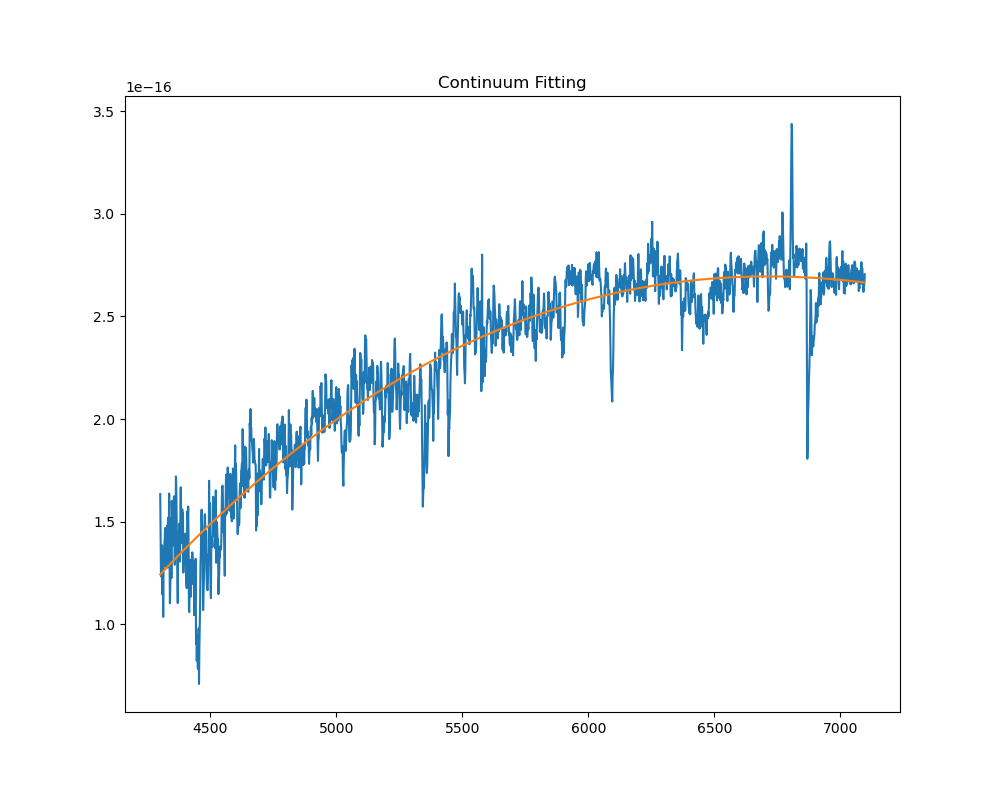

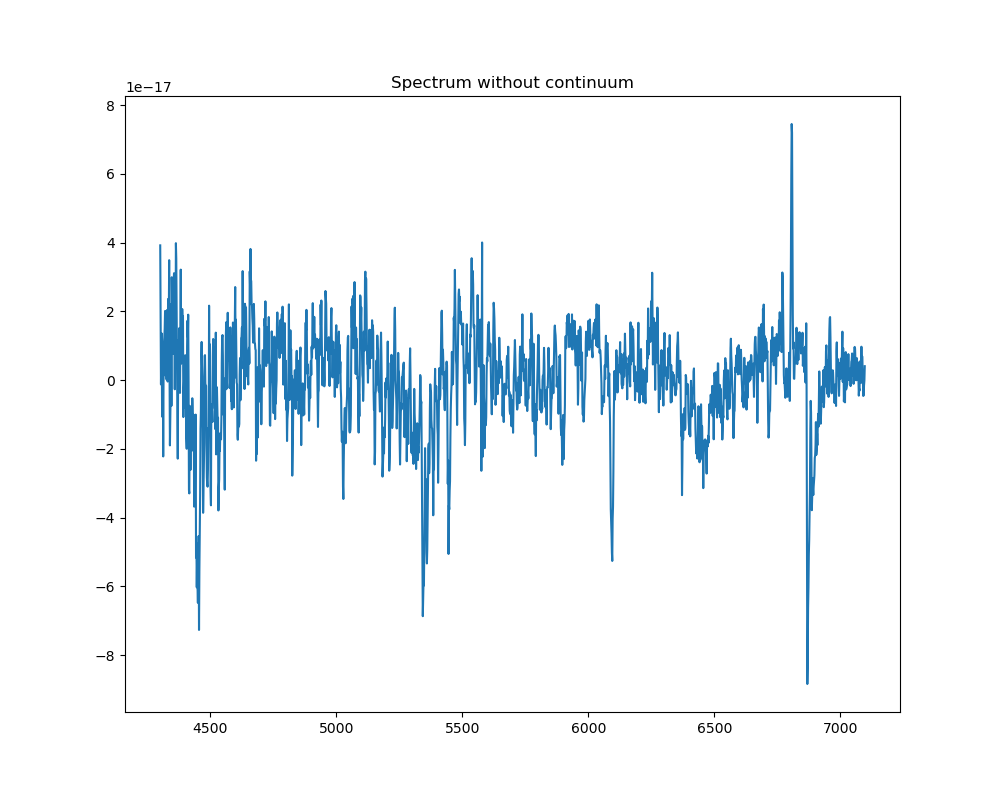

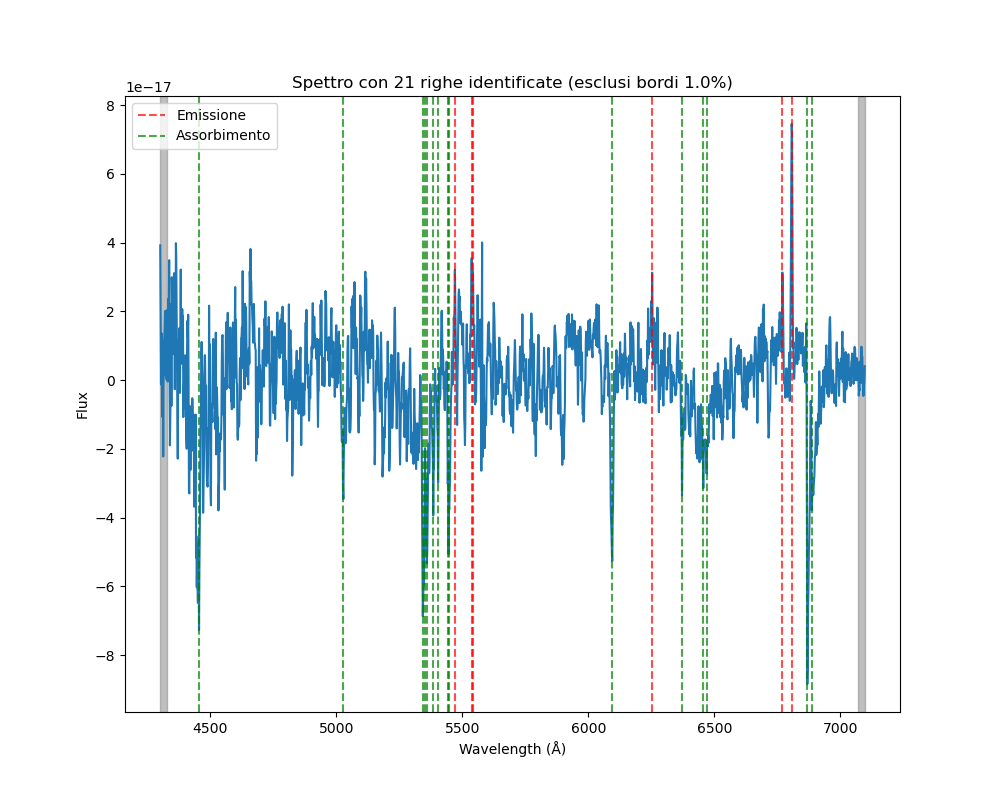

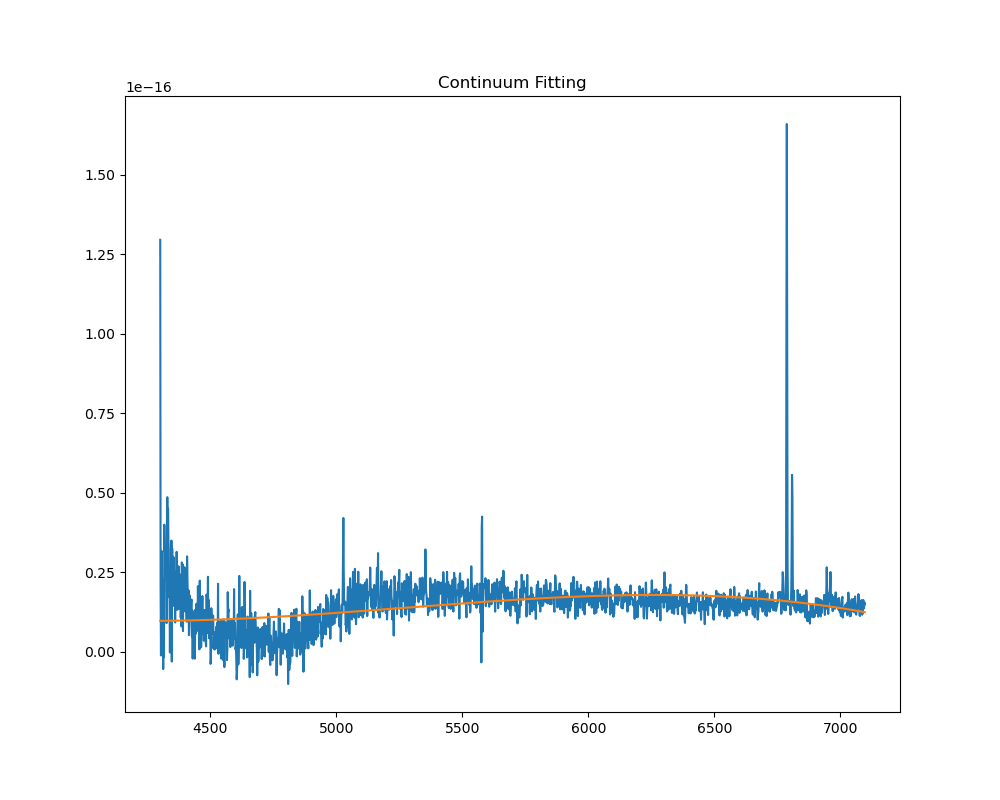

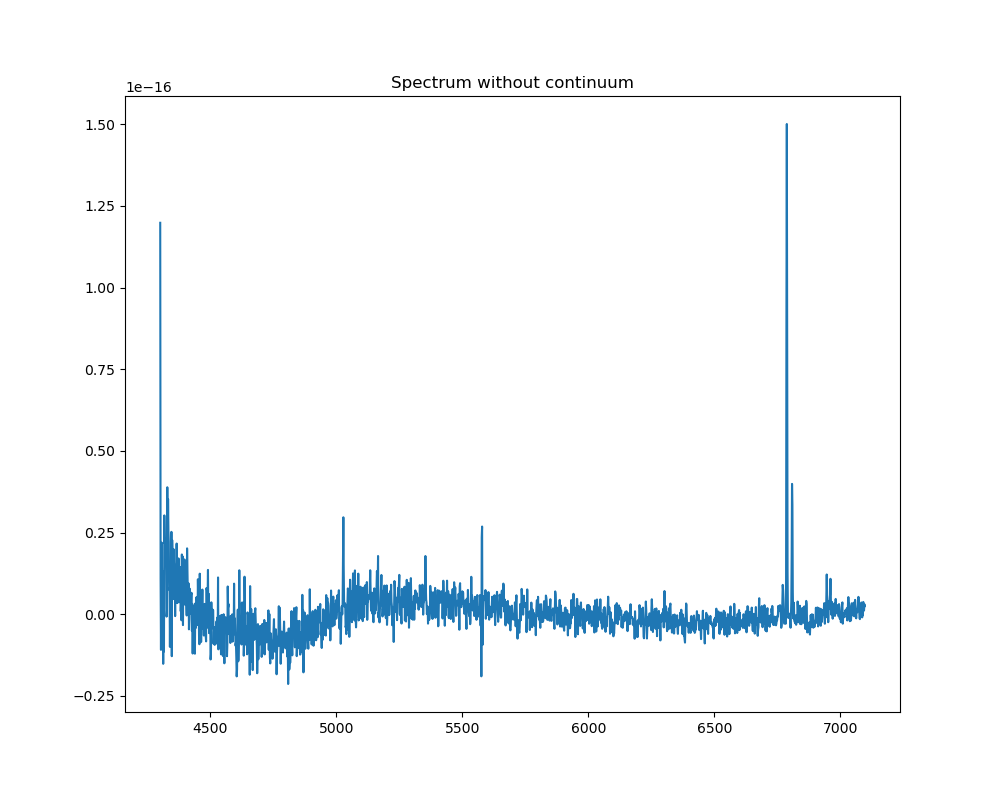

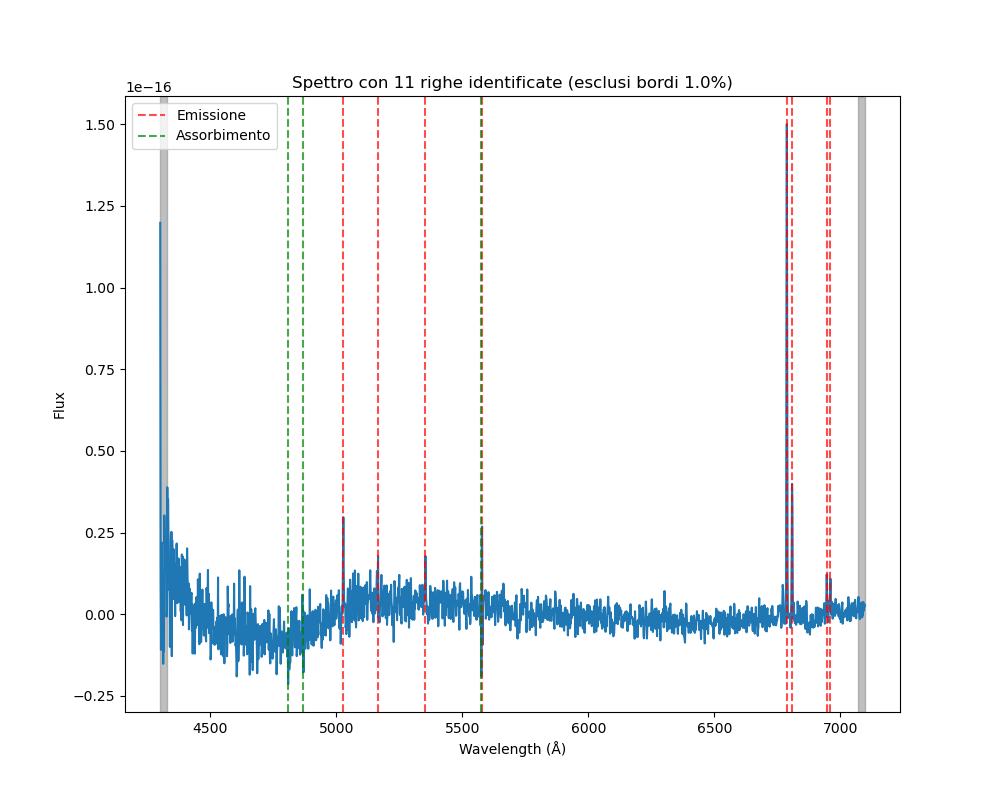

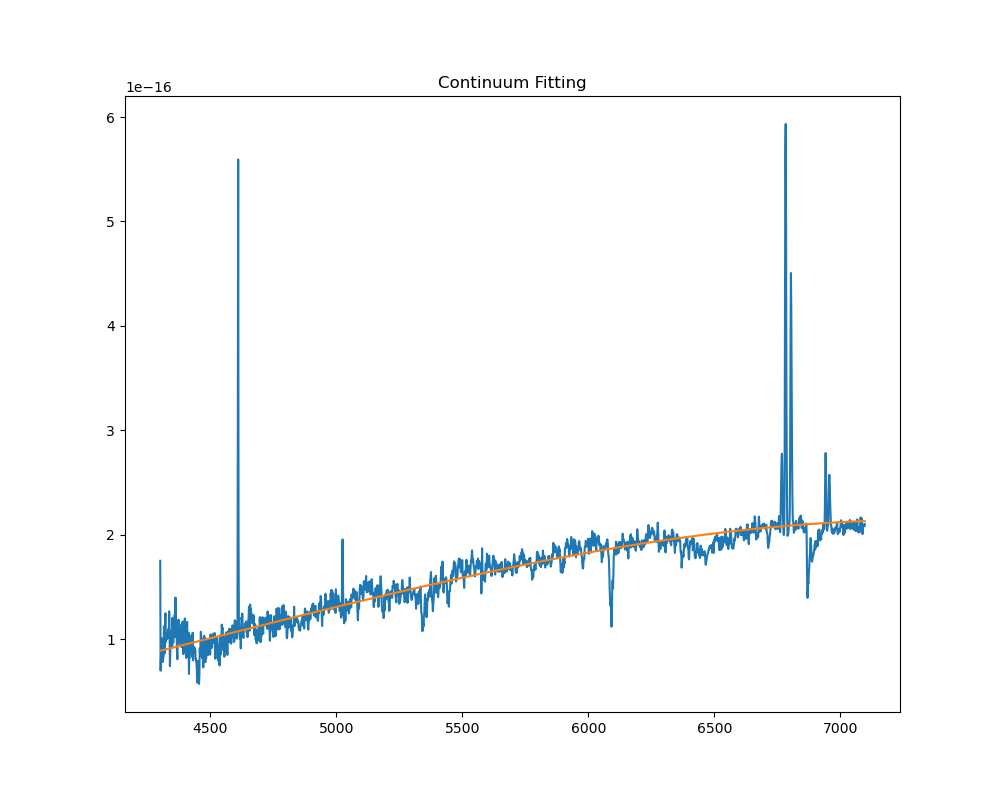

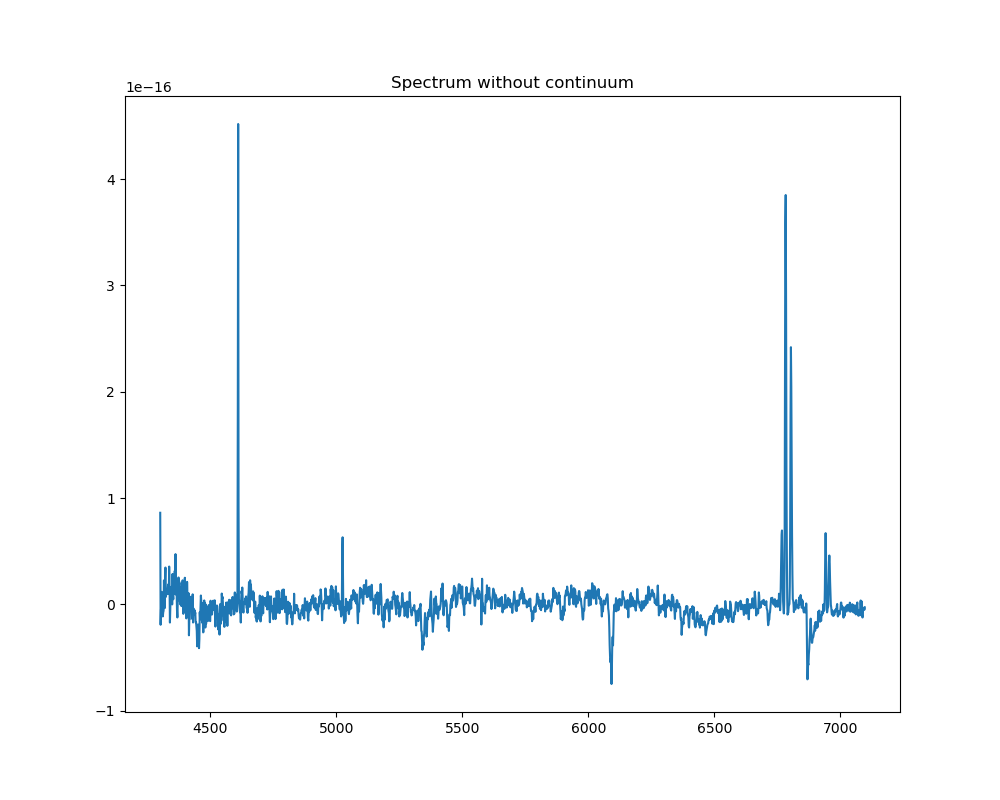

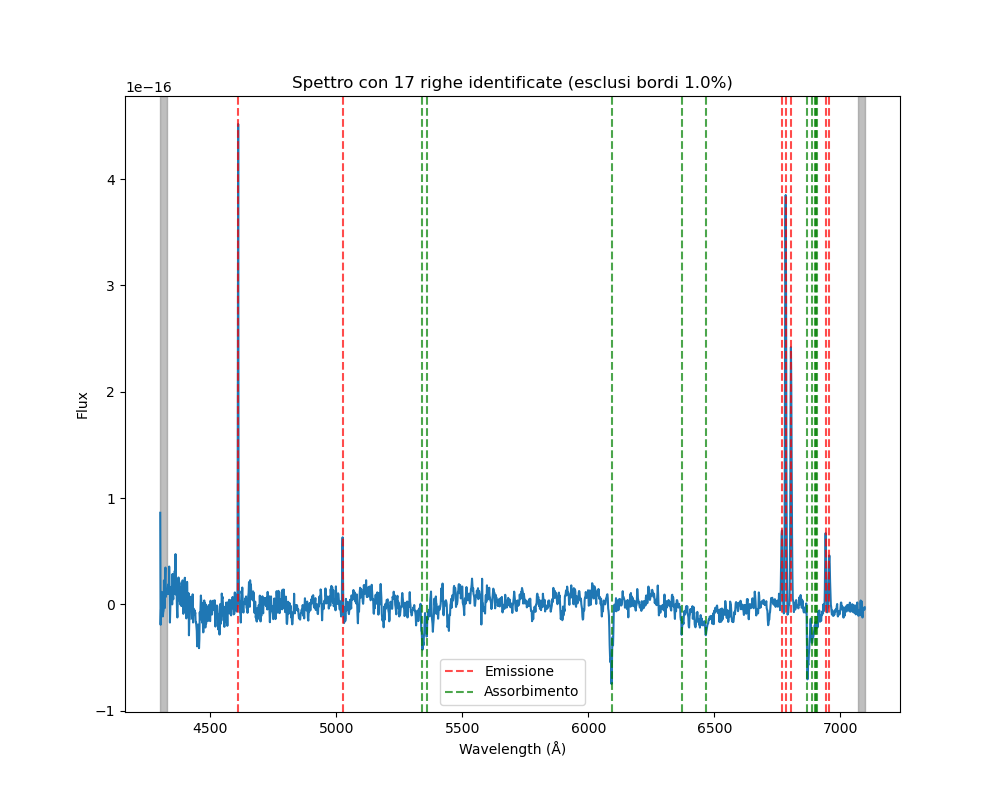

In [14]:
all_lines = []
noise_factor = [6, 4, 6]

# Definisci la percentuale di spettro da escludere ai bordi (es. 5% per lato)
edge_fraction = 0.01
n_points = len(wv)
start_idx = int(n_points * edge_fraction)
end_idx = int(n_points * (1 - edge_fraction))

# Crea gli array ritagliati per la regione centrale
wv_central = wv[start_idx:end_idx]

for i in range(len(peaks)):
    # Usa tutto lo spettro per il fitting del continuum
    spectrum = Spectrum(
        spectral_axis=wv * u.Angstrom,
        flux = spectra_3[i]* 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom),  
        uncertainty = StdDevUncertainty(spectra_err_3[i]* 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    g1_fit = fit_generic_continuum(spectrum, fitter=LinearLSQFitter())
    y_continuum_fitted = g1_fit(wv * u.Angstrom)
    f, ax = plt.subplots(figsize = (10,8))
    ax.plot(wv * u.Angstrom, spectra_3[i]* 1e-16*u.erg / (u.cm**2 * u.s * u.Angstrom))
    ax.plot(wv * u.Angstrom, y_continuum_fitted)
    ax.set_title("Continuum Fitting")
    
    flux_continuum_subtracted = spectrum.flux - y_continuum_fitted
    f2, ax2 = plt.subplots(figsize = (10,8))
    ax2.plot(wv * u.Angstrom, flux_continuum_subtracted)
    
    ax2.set_title("Spectrum without continuum")
    
    # Crea lo spettro solo per la regione centrale (senza bordi)
    spectrum_no_continuum_central = Spectrum(
        spectral_axis=wv_central * u.Angstrom,
        flux=flux_continuum_subtracted[start_idx:end_idx],
        uncertainty=StdDevUncertainty(spectra_err_3[i][start_idx:end_idx] * 1e-16 * u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    # Trova le righe solo nella regione centrale
    lines = find_lines_threshold(spectrum_no_continuum_central, noise_factor = noise_factor[i])
    print(f"Numero di righe trovate (regione centrale): {len(lines)}")
    print(lines)
    
    f3, ax3 = plt.subplots(figsize=(10,8))
    ax3.plot(wv, flux_continuum_subtracted.value)
    
    if len(lines) < 50:  # Solo se non sono troppe
        for line_pos in lines['line_center']:
            # Trova l'indice corrispondente alla lunghezza d'onda della riga
            line_wavelength = line_pos.value
            idx = np.argmin(np.abs(wv - line_wavelength))
            
            # Determina il valore del flusso alla posizione della riga
            flux_value = flux_continuum_subtracted.value[idx]
            
            # Colora in base al segno del flusso
            if flux_value > 0:
                # Riga di emissione - rosso
                color = 'red'
                label = 'Emissione'
            else:
                # Riga di assorbimento - verde
                color = 'green' 
                label = 'Assorbimento'
            
            ax3.axvline(x=line_pos.value, color=color, alpha=0.7, linestyle='--')
    
    # Aggiungi linee verticali per indicare i bordi esclusi
    ax3.axvspan(wv[0], wv[start_idx], alpha=0.5, color='gray', zorder=1, label='Regione esclusa')
    ax3.axvspan(wv[end_idx-1], wv[-1], alpha=0.5, color='gray', zorder=1)
    #ax3.axvline(x=wv[start_idx], color='gray', alpha=0.5, linestyle='-', linewidth=2, label='Regione esclusa')
    #ax3.axvline(x=wv[end_idx-1], color='gray', alpha=0.5, linestyle='-', linewidth=2)
    ax3.legend()
    
    ax3.set_title(f"Spettro con {len(lines)} righe identificate (esclusi bordi {edge_fraction*100:.1f}%)")
    ax3.set_xlabel('Wavelength (Å)')
    ax3.set_ylabel('Flux')   

    # Aggiungi una legenda per distinguere emissione e assorbimento
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color='red', linestyle='--', alpha=0.7, label='Emissione'),
                      Line2D([0], [0], color='green', linestyle='--', alpha=0.7, label='Assorbimento')]
    ax3.legend(handles=legend_elements)
    
    all_lines.append(lines)

In [15]:
6731.3*(1+z)

6960.231513000001

In [16]:
#reference wv in air
l_Hgam = 4340.5
l_HA = 6562.8
l_HB = 4861.3
l_NII_1 = 6548.1
l_NII_2 = 6583.4
l_SII_1 = 6717.0
l_SII_2 = 6731.3
l_OIII_1 = 4958.9
l_OIII_2 = 5006.8
l_He_1 = 5875.6
l_OI = 6300.3

lines_1 = [l_HB, l_NII_1, l_NII_2]
lines_2 = [l_HB, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_3 = [l_HB, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_spectrum_1 = [5027.419999999785, 6769.379999999272, 6806.379999999261]
lines_spectrum_2 = [5027.419999999785, 6787.139999999266,  6807.85999999926, 6945.49999999922, 6960.299999999215] 
lines_spectrum_3 = [5024.459999999786, 6767.899999999272,  6782.699999999268,  6803.419999999262, 6941.059999999221, 6955.859999999217]

def redshift(lines, lines_spectrum):
    z = np.zeros(len(lines))
    for i in range(len(lines)):
        z[i] = lines_spectrum[i].value / lines[i] - 1
    z_mean = np.mean(z)
    z_std = np.std(z)
    return z_mean, z_std
    
def redshift_hand(lines, lines_spectrum):
    z = np.zeros(len(lines))
    for i in range(len(lines)):
        z[i] = lines_spectrum[i]/ lines[i] - 1
    z_mean = np.mean(z)
    z_std = np.std(z)
    return z_mean, z_std 

z_1_mean, z_1_std = redshift_hand(lines_1, lines_spectrum_1)
z_2_mean, z_2_std = redshift_hand(lines_2, lines_spectrum_2)
z_3_mean, z_3_std = redshift_hand(lines_3, lines_spectrum_3) 

z = [z_1_mean, z_2_mean, z_3_mean]
z_err = [z_1_std, z_2_std, z_3_std]

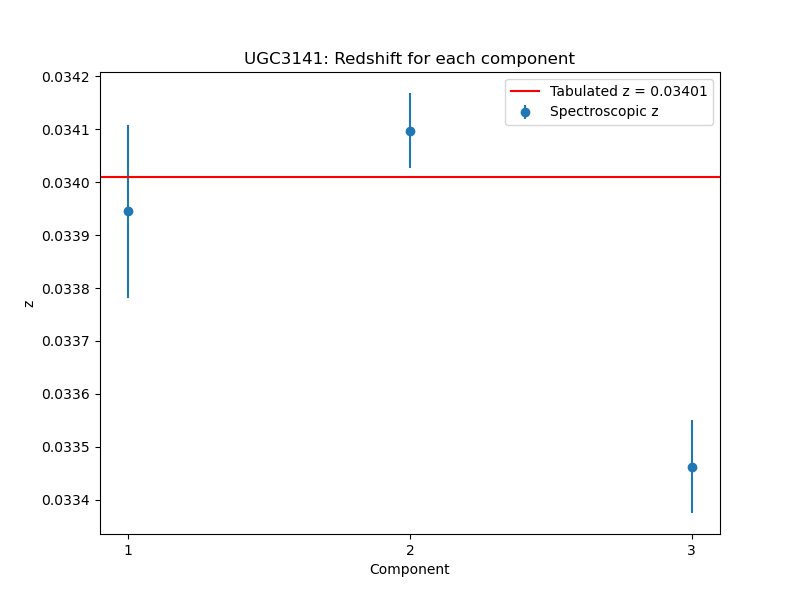

In [17]:
plt.figure(figsize=(8, 6))
comp = [1, 2, 3]
plt.errorbar(comp, z, z_err, ls='none', marker = 'o', label = 'Spectroscopic z')
plt.xlabel('Component')
plt.ylabel('z')
plt.xticks(comp)
plt.axhline(0.03401, color = 'red', label = 'Tabulated z = 0.03401')
plt.title('UGC3141: Redshift for each component')
plt.legend()
plt.savefig('Redshift_UGC3141', bbox_inches='tight')

red_table = np.column_stack((z, z_err))
np.savetxt('redshift.txt', red_table, header='redshift redshift_error', fmt='%.5f',delimiter='\t')

## S/N emission lines 

In [18]:
def SNR_line(wv, wv_line, spectra, peaks): 
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        left_region = (wv > wv_line[i]-15)*(wv < wv_line[i]-5) 
        right_region = (wv > wv_line[i]+5)*(wv < wv_line[i]+15) 
        clean_mask = left_region | right_region

        mask = (wv > wv_line[i]-4)*(wv < wv_line[i]+4)
        wv_bin = np.array(np.where(mask == True))
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
   # print(SNR)
   # print(Signal)
   # print(Noise)
    return SNR, Signal, Noise
    
def SNR_OIII_line(wv, OIII_1, OIII_2, wv_line, spectra, peaks):
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        left_region = (wv > OIII_1[i]-15)*(wv < OIII_1[i]-5) 
        right_region = (wv > OIII_2[i]+5)*(wv < OIII_2[i]+15) 
        clean_mask = left_region | right_region

        mask = (wv > wv_line[i]-4)*(wv < wv_line[i]+4)
        wv_bin = np.array(np.where(mask == True))
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise 
    
def SNR_SII_line(wv, SII_1, SII_2, wv_line, spectra, peaks):
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        left_region = (wv > SII_1[i]-15)*(wv < SII_1[i]-5) 
        right_region = (wv > SII_2[i]+5)*(wv < SII_2[i]+15) 
        clean_mask = left_region | right_region

        mask = (wv > wv_line[i]-4)*(wv < wv_line[i]+4)
        wv_bin = np.array(np.where(mask == True))
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise 

def SNR_HA_NII(wv, NII_1, NII_2, wv_line, spectra, peaks):
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        left_region = (wv > NII_1[i]-15)*(wv < NII_1[i]-5) 
        right_region = (wv > NII_2[i]+5)*(wv < NII_2[i]+15) 
        clean_mask = left_region | right_region

        mask = (wv > wv_line[i]-4)*(wv < wv_line[i]+4)
        wv_bin = np.array(np.where(mask == True))
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise  

In [19]:
l_Hgam = []
l_HA = []
l_HB = []
l_NII_1 = []
l_NII_2 = []
l_SII_1 = []
l_SII_2 = []
l_OIII_1 = []
l_OIII_2 = []
l_He_1 = []
l_HeII = []
l_OI = []
for i in range(len(spectra_1)):
    l_Hgam.append(4340.5*(1+z[i]))
    l_HA.append(6562.8*(1+z[i]))
    l_HB.append(4861.3*(1+z[i]))
    l_NII_1.append(6548.1*(1+z[i]))
    l_NII_2.append(6583.4*(1+z[i]))
    l_SII_1.append(6717.0*(1+z[i]))
    l_SII_2.append(6731.3*(1+z[i]))
    l_OIII_1.append(4958.9*(1+z[i]))
    l_OIII_2.append(5006.8*(1+z[i]))
    l_He_1.append(5875.6*(1+z[i]))
    l_HeII.append(4685.7*(1+z[i]))
    l_OI.append(6300.3*(1+z[i]))

In [20]:
def save_snr_HB(wv, l_HB, spectra_list, peaks, output_dirs, file_prefixes):
    """
    Generalizza l'analisi SNR per multiple spectra
    
    Parameters:
    - wv: wavelength array
    - l_HB: line parameter
    - spectra_list: lista degli spettri da analizzare
    - peaks: peaks parameter
    - output_dirs: lista delle directory di output
    - file_prefixes: lista dei prefissi per i nomi dei file
    """
    
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_line(wv, l_HB, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')
        print(f'{file_prefix}.csv', df)

def save_snr_OIII(wv, OIII_1, OIII_2, wv_line, spectra_list, peaks, output_dirs, file_prefixes):
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_OIII_line(wv, OIII_1, OIII_2, wv_line, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')
        print(f'{file_prefix}.csv', df)
        
def save_snr_SII(wv, SII_1, SII_2, wv_line, spectra_list, peaks, output_dirs, file_prefixes):
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_SII_line(wv, SII_1, SII_2, wv_line, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')
        print(f'{file_prefix}.csv', df)


def save_snr_HA_NII(wv, NII_1, NII_2, wv_line, spectra_list, peaks, output_dirs, file_prefixes):
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_HA_NII(wv, NII_1, NII_2, wv_line, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')
        print(f'{file_prefix}.csv', df)

def save_snr(wv, wv_line, spectra_list, peaks, output_dirs, file_prefixes):
    
    for i, (spectra, output_dir, file_prefix) in enumerate(zip(spectra_list, output_dirs, file_prefixes)):
        # Calcola SNR per lo spettro corrente
        SNR, signal, noise = SNR_line(wv, wv_line, spectra, peaks)
        
        # Crea il DataFrame
        df = pd.DataFrame({
        'SNR': SNR,
        'Signal': signal,
        'Noise': noise }, index=[f'Component_{i}' for i in range(1, len(peaks)+ 1)])
        
        # Salva il file CSV
        df_path = os.path.join(output_dir, f'{file_prefix}.csv')
        df.to_csv(df_path, float_format='%.3f')
        print(f'{file_prefix}.csv', df)

In [21]:
spectra_list = [spectra_1, spectra_2, spectra_3]
output_dirs = ['1Sigma', '2Sigma', '3Sigma']
file_prefixes = ['SNR_HB_1s', 'SNR_HB_2s', 'SNR_HB_3s']
save_snr_HB(wv, l_HB, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_OIII_1_1s', 'SNR_OIII_1_2s', 'SNR_OIII_1_3s']
save_snr_OIII(wv, l_OIII_1, l_OIII_2, l_OIII_1, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_OIII_2_1s', 'SNR_OIII_2_2s', 'SNR_OIII_2_3s']
save_snr_OIII(wv, l_OIII_1, l_OIII_2, l_OIII_2, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_SII_1_1s', 'SNR_SII_1_2s', 'SNR_SII_1_3s']
save_snr_SII(wv, l_SII_1, l_SII_2, l_SII_1, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_SII_2_1s', 'SNR_SII_2_2s', 'SNR_SII_2_3s']
save_snr_SII(wv, l_SII_1, l_SII_2, l_SII_2, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_NII_1_1s', 'SNR_NII_1_2s', 'SNR_NII_1_3s']
save_snr_HA_NII(wv, l_NII_1, l_NII_2, l_NII_1, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_NII_2_1s', 'SNR_NII_2_2s', 'SNR_NII_2_3s']
save_snr_HA_NII(wv, l_NII_1, l_NII_2, l_NII_2, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_HA_1s', 'SNR_HA_2s', 'SNR_HA_3s']
save_snr_HA_NII(wv, l_NII_1, l_NII_2, l_HA, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_HeII_1s', 'SNR_HeII_2s', 'SNR_HeII_3s']
save_snr(wv, l_HeII, spectra_list, peaks, output_dirs, file_prefixes)

file_prefixes = ['SNR_OI_1s', 'SNR_OI_2s', 'SNR_OI_3s']
save_snr(wv, l_OI, spectra_list, peaks, output_dirs, file_prefixes)

SNR_HB_1s.csv                   SNR    Signal     Noise
Component_1 -2.780401 -0.547161  0.196792
Component_2  7.737377  0.585096  0.075619
Component_3  5.788984  0.823195  0.142200
SNR_HB_2s.csv                   SNR    Signal     Noise
Component_1 -3.128098 -0.848441  0.271232
Component_2  6.419445  0.887437  0.138242
Component_3  8.995250  1.908887  0.212211
SNR_HB_3s.csv                   SNR    Signal     Noise
Component_1 -4.505575 -1.121260  0.248861
Component_2  8.081621  1.023342  0.126626
Component_3  9.537257  2.364689  0.247942
SNR_OIII_1_1s.csv                   SNR    Signal     Noise
Component_1  0.431745  0.142923  0.331035
Component_2 -0.910318 -0.065608  0.072071
Component_3  1.845526  0.401271  0.217429
SNR_OIII_1_2s.csv                   SNR    Signal     Noise
Component_1  0.544692  0.299194  0.549290
Component_2  0.719682  0.069290  0.096279
Component_3  1.229043  0.435803  0.354587
SNR_OIII_1_3s.csv                   SNR    Signal     Noise
Component_1  0.521814 

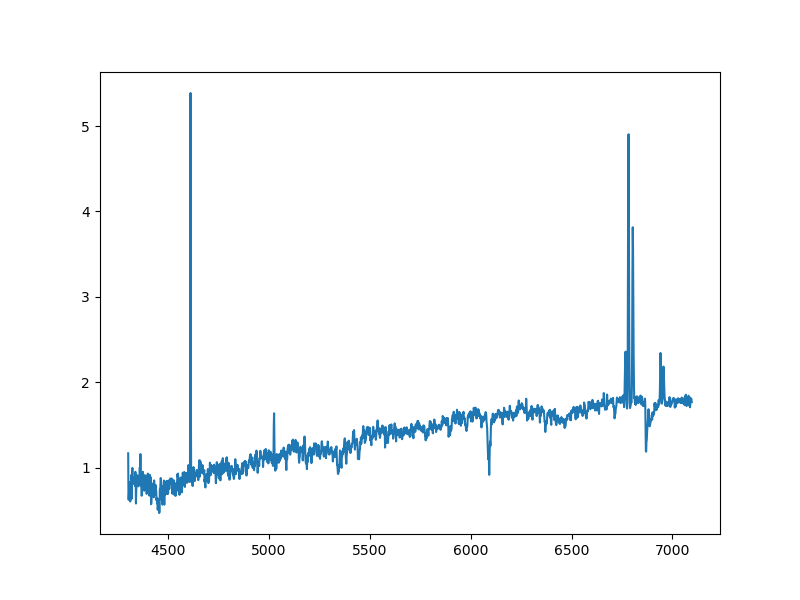

In [27]:
plt.figure(figsize=(8,6))
plt.plot(wv, spectra_2[2])

In [25]:
l_OI

[6514.163630445535, 6515.1259804686115, 6511.124010414991]